In [16]:
import numpy as np
import matplotlib.pyplot as plt


from thermosim.utils.io import load_irb_txt

In [17]:
from pathlib import Path

folder = Path("../data/Thermografiemessungen/Lochplatten - transiente Abkühlung/ThSi_Messung2_Lochplatte_klein")
csv_files = sorted(folder.glob("*.csv"))
print(f"Found {len(csv_files)} files")

frames = []
for f in csv_files:
    arr, settings, params = load_irb_txt(str(f))
    frames.append({"arr": arr, "settings": settings, "params": params})

print("Data shape per frame:", frames[0]["arr"].shape)
print("Settings:", frames[0]["settings"])
print("Params:", frames[0]["params"])

Found 9 files
Data shape per frame: (333, 507)
Settings: {'Version': 3, 'ImageWidth': 507, 'ImageHeight': 333, 'ShotRange': [21.6, 53.6], 'CalibRange': [-40.15, 119.85], 'TempUnit': '°C', 'StartPos': [42, 90], 'EndPos': [548, 422]}
Params: {'Filename': 'Laminiertisch gross_0002.irb', 'FrameIndex': 2, 'RecDate': '04.12.2025', 'RecTime': '14:41:36', 'ms': 30018.75}


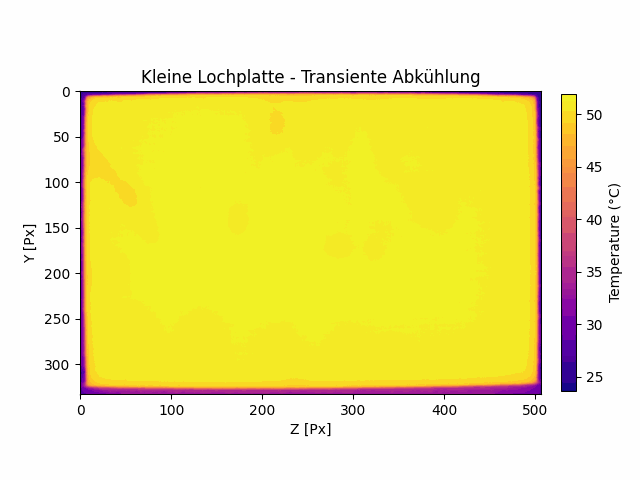

In [18]:
import matplotlib.animation as animation
from IPython.display import Image as IPyImage

all_arrs = [f["arr"] for f in frames]
vmin = min(a.min() for a in all_arrs)
vmax = max(a.max() for a in all_arrs)

fig, ax = plt.subplots()
im = ax.imshow(all_arrs[0], cmap="plasma", vmin=vmin, vmax=vmax)
plt.colorbar(im, ax=ax, fraction=0.03, pad=0.04, label="Temperature (°C)")
ax.set_title("Kleine Lochplatte - Transiente Abkühlung")
ax.set_xlabel("Z [Px]")
ax.set_ylabel("Y [Px]")

def update(i):
    im.set_data(all_arrs[i])
    return (im,)

ani = animation.FuncAnimation(fig, update, frames=len(all_arrs), interval=300, blit=True)
ani.save("../results/cooling.gif", writer="pillow", dpi=100)
plt.close()

IPyImage("../results/cooling.gif")

In [23]:
import cv2
def undistort_image(img, K, dist, alpha=0.0):
    """
    alpha=0.0 -> crop to valid pixels (no black border)
    alpha=1.0 -> keep all pixels (more black border)
    """
    h, w = img.shape[:2]
    newK, roi = cv2.getOptimalNewCameraMatrix(K, dist, (w, h), alpha, (w, h))
    und = cv2.undistort(img, K, dist, None, newK)
    return und, newK, roi

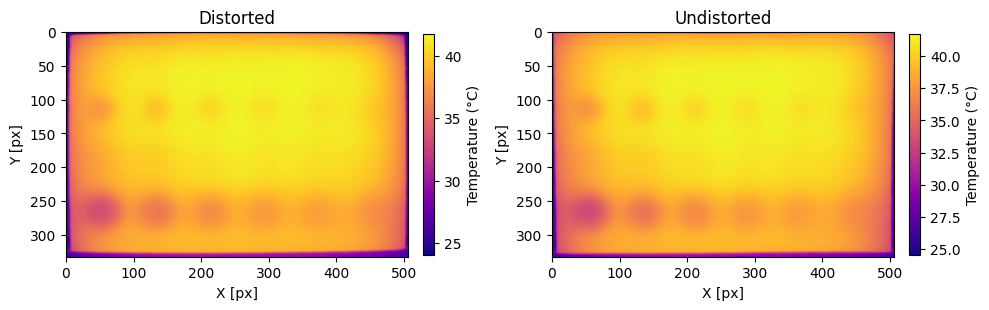

In [27]:
K = np.array([
    [1.18582369e+03, 0.00000000e+00, 2.19387775e+02],
    [0.00000000e+00, 1.84546067e+03, 2.02390039e+02],
    [0.00000000e+00, 0.00000000e+00, 1.00000000e+00]
], dtype=np.float64)

dist = np.array([
    -0.43945233,
    -8.25204395,
    0.02161391,
    0.01624099,
    0.
], dtype=np.float64)

arr = frames[5]["arr"]
img_, _, _ = undistort_image(arr, K, dist)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for ax, data, title in zip(axes, [arr, img_], ["Distorted", "Undistorted"]):
    im = ax.imshow(data, cmap="plasma")
    ax.set_title(title)
    ax.set_xlabel("X [px]")
    ax.set_ylabel("Y [px]")
    plt.colorbar(im, ax=ax, fraction=0.03, pad=0.04, label="Temperature (°C)")

plt.tight_layout()
plt.show()

In [6]:
import plotly.express as px
fig = px.imshow(arr, color_continuous_scale="plasma",title="Temperature")
fig.show()